# **Long-term Annual & Seasonal Rainfall Trends**

**Study Period:** 1900 - 2025

**Seasonal Breakdown:** 
 - Summer (December, January & February)
 - Autumn (March, April & May)
 - Winter (June, July & August)
 - Spring (September, October & November)

**Script Output:**
 - mornington_annual_rainfall_trend.png
 - mornington_seasonal_rainfall_trends.png

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk

# Mornington Peninsula bounding box
lat_min, lat_max = -38.50, -38.05
lon_min, lon_max = 144.68, 145.35


CACHE_DIR = '/scratch/ob22/ft3359/mornington_cache'

precip_grid = xr.open_dataarray(f'{CACHE_DIR}/precip_gird_masked.nc').load()
tmax_grid = xr.open_dataarray(f'{CACHE_DIR}/tmax_grid_masked.nc').load()
tmin_grid = xr.open_dataarray(f'{CACHE_DIR}/tmin_grid_masked.nc').load()
LAND_MASK = xr.open_dataarray(f'{CACHE_DIR}/land_mask.nc').load()

print(f"Loaded cached grids: lat={precip_grid.lat.size}, lon={precip_grid.lon.size}, "
      f"time={precip_grid.time.size}")

# Spatial mean over the box
precip_box_mean = precip_grid.mean(dim=['lat', 'lon'], skipna=True)

/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)


Loaded cached grids: lat=10, lon=14, time=46021


In [2]:
# Helper: Mann-Kendall trend Stats

def trend_stats(years, values):
    # Return dict with Mann-Kendall/Sen's slope trend stats
    mask = ~np.isnan(values)
    years_c, values_c = years[mask], values[mask]

    mk_result = mk.original_test(values_c)

    # Sen's slope is per unit of the index (i.e. per year here)
    sen_slope_per_decade = mk_result.slope * 10

    # Theil-Sen intercept convention: median(y) - slope * median(x)
    sen_intercept = np.median(values_c) - mk_result.slope * np.median(years_c)

    out = {
        'sen_slope_per_decade': sen_slope_per_decade,
        'sen_intercept': sen_intercept,
        'mk_p': mk_result.p,
        'mk_z': mk_result.z,
        'n_years': len(years_c),
    }
    return out

def fmt_trend_label(stats_dict):
    sig = 'significant' if stats_dict['mk_p'] < 0.05 else 'not significant'
    return f"p={stats_dict['mk_p']:.3f} ({sig})"

Dropped 0 incomplete year(s) from annual series (out of 126).
Annual rainfall trend (Mann-Kendall / Sen's slope)
{'sen_slope_per_decade': -1.7789077758789062, 'sen_intercept': 1075.1814517974854, 'mk_p': 0.5078724794723803, 'mk_z': -0.6621540807708504, 'n_years': 126}
Saved: mornington_annual_rainfall_trend.png


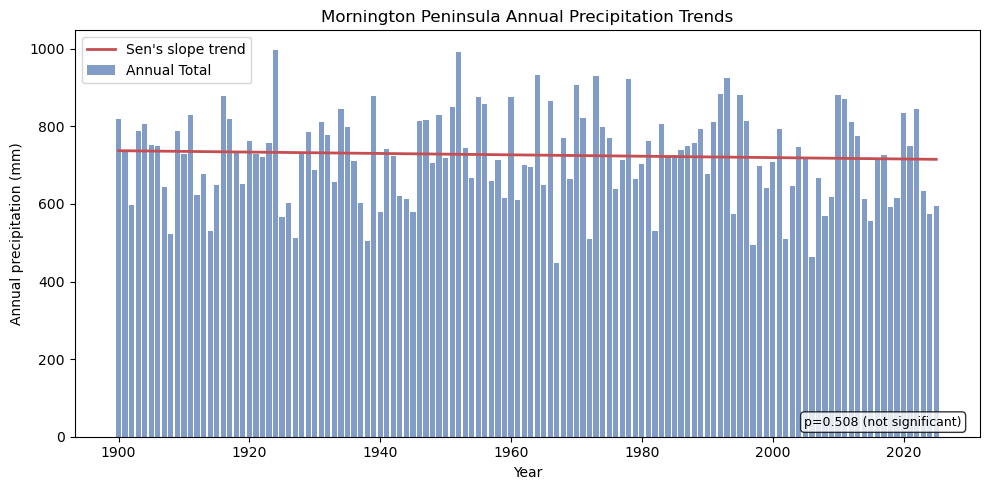

In [4]:
# Annual rainfall trend
annual_total = precip_box_mean.resample(time='YS').sum(skipna=True)
annual_count = precip_box_mean.resample(time='YS').count()
annual_expected = annual_total['time'].dt.is_leap_year.astype(int) * 366 + \
                    (~annual_total['time'].dt.is_leap_year).astype(int) * 365

complete_mask = (annual_count / annual_expected) >= 0.9
annual_total_clean = annual_total.where(complete_mask)

print(f"Dropped {int((~complete_mask).sum())} incomplete year(s) from annual series "
      f"(out of {annual_total.time.size}).")

annual_total_clean = annual_total_clean.compute()

years = annual_total_clean['time'].dt.year.values.astype(float)
values = annual_total_clean.values
annual_trend = trend_stats(years, values)

print("Annual rainfall trend (Mann-Kendall / Sen's slope)")
print(annual_trend)

# Plot

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(years, values, color='#4C72B0', alpha=0.7, label='Annual Total')

mask = ~np.isnan(values)
fit_line = annual_trend['sen_intercept'] + (annual_trend['sen_slope_per_decade'] / 10) * years[mask]
ax.plot(years[mask], fit_line, color='#C44E52', linewidth=2, label="Sen's slope trend")

ax.set_title('Mornington Peninsula Annual Precipitation Trends')
ax.set_xlabel('Year')
ax.set_ylabel('Annual precipitation (mm)')
ax.legend(loc='upper left')
ax.text(0.98, 0.02, fmt_trend_label(annual_trend),
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
fig.tight_layout()
fig.savefig('mornington_annual_rainfall_trend.png', dpi=200)
print("Saved: mornington_annual_rainfall_trend.png")

Saved: mornington_seasonal_rainfall_trends.png
Seasonal rainfall trends summary (Mann-Kendall / Sen's slope)
(a) DJF: p=0.806 (not significant)
(b) MAM: p=0.063 (not significant)
(c) JJA: p=0.823 (not significant)
(d) SON: p=0.264 (not significant)


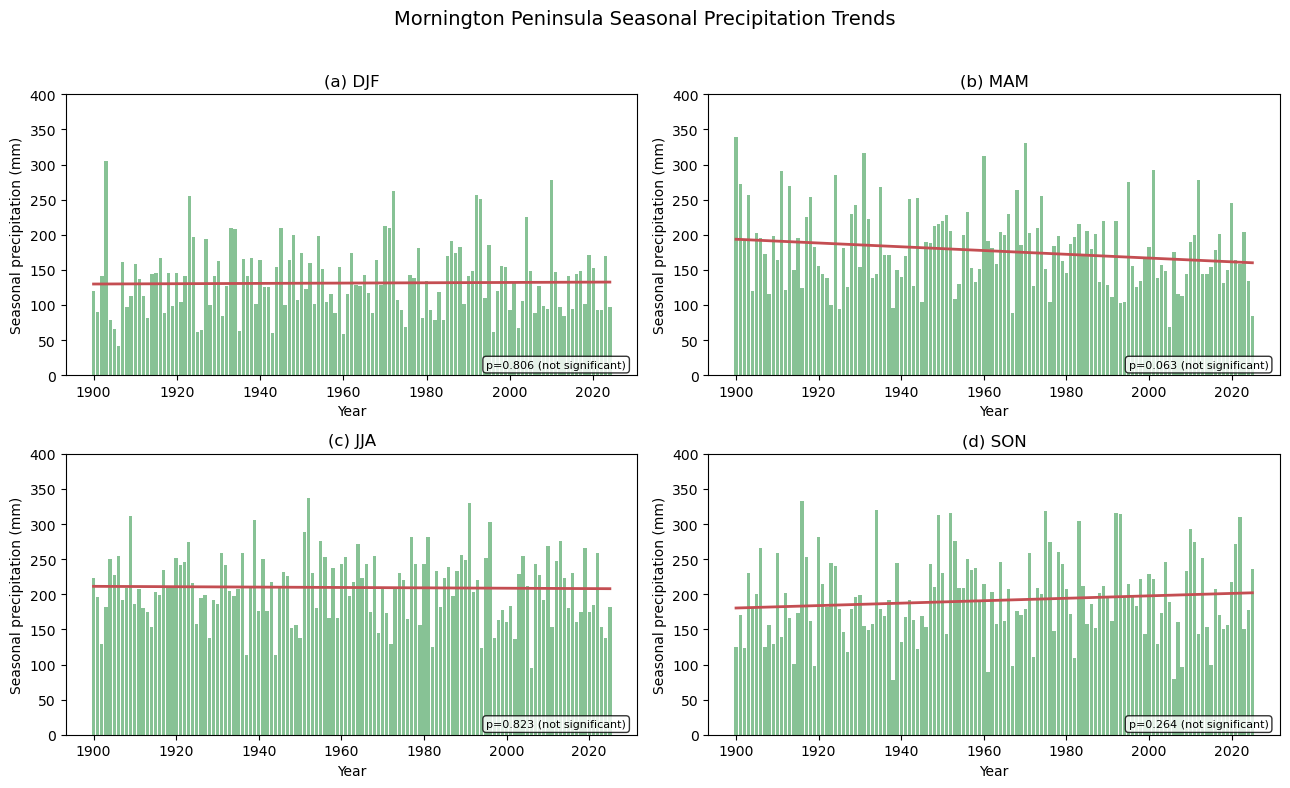

In [7]:
# Seasonal Rainfall Trends (DJF, MAM, JJA, SON)

# QS-DEC anchors seasons on Dec/Mar/Jun/Sep, so DJF spans Dec(year) - Feb(year+1)
seasonal_total = precip_box_mean.resample(time='QS-DEC').sum(skipna=True)
seasonal_count = precip_box_mean.resample(time='QS-DEC').count()
 
# Build expected day counts per season (~90, 91, or 92 days depending on season/leap year)
def days_in_season(ts):
    end = ts + pd.DateOffset(months=3)
    return (end - ts).days
 
expected_days_arr = np.array([days_in_season(pd.Timestamp(t)) for t in seasonal_total['time'].values])
seasonal_complete_mask = (seasonal_count.values / expected_days_arr) >= 0.9
seasonal_total_clean = seasonal_total.where(xr.DataArray(seasonal_complete_mask, dims='time',
                                                           coords={'time': seasonal_total.time}))
seasonal_total_clean = seasonal_total_clean.compute()
 
season_names = {12: '(a) DJF', 3: '(b) MAM', 6: '(c) JJA', 9: '(d) SON'}
season_labels = seasonal_total_clean['time'].dt.month.values
season_years = seasonal_total_clean['time'].dt.year.values
 
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
axes = axes.flatten()
season_order = [12, 3, 6, 9]  # DJF, MAM, JJA, SON
 
seasonal_results = {}
 
for ax, month in zip(axes, season_order):
    sel = season_labels == month
    yrs = season_years[sel].astype(float)
    vals = seasonal_total_clean.values[sel]
 
    tstats = trend_stats(yrs, vals)
    seasonal_results[season_names[month]] = tstats
 
    ax.bar(yrs, vals, color='#55A868', alpha=0.7)
 
    mask = ~np.isnan(vals)
    fit_line = tstats['sen_intercept'] + (tstats['sen_slope_per_decade'] / 10) * yrs[mask]
    ax.plot(yrs[mask], fit_line, color='#C44E52', linewidth=2)
 
    ax.set_title(season_names[month])
    ax.set_xlabel('Year')
    ax.set_ylabel('Seasonal precipitation (mm)')
    ax.set_ylim(0, 400)
    ax.text(0.98, 0.02, fmt_trend_label(tstats),
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
 
fig.suptitle('Mornington Peninsula Seasonal Precipitation Trends', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('mornington_seasonal_rainfall_trends.png', dpi=200)
print("Saved: mornington_seasonal_rainfall_trends.png")
 
print("Seasonal rainfall trends summary (Mann-Kendall / Sen's slope)")
for season, tstats in seasonal_results.items():
    print(f"{season}: {fmt_trend_label(tstats)}")

**Interannual Variability: Coefficient of Variation (CV) and IQR**

In [11]:
def variability_stats(values):
    # Return dict with CV and IQR for a 1D array of annual/seasonal totals
    v = values[~np.isnan(values)]
    mean = np.mean(v)
    sd = np.std(v, ddof=1) # sample standard deviation
    cv = sd / mean if mean != 0 else np.nan
    q75, q25 = np.percentile(v, [75, 25])
    iqr = q75 - q25
    return {
        'mean_mm': mean, 
        'sd_mm': sd,
        'cv': cv,
        'iqr_mm': iqr,
        'q25_mm': q25,
        'q75_mm': q75,
        'n_years': len(v),
    }

def fmt_variability(vstats):
    return (f"mean={vstats['mean_mm']:.0f}mm, SD={vstats['sd_mm']:.0f}mm, "
            f"CV={vstats['cv']:.2f}, IQR={vstats['iqr_mm']:.0f}mm "
            f"(Q25={vstats['q25_mm']:.0f}, Q75={vstats['q75_mm']:.0f})")

# Annual Variability
annual_variability = variability_stats(values)
print("\nAnnual rainfall variability")
print(fmt_variability(annual_variability))

# Seasonal Variability
print("\nSeasonal rainfall variability")
seasonal_variability= {}
for month in season_order:
    sel = season_labels == month
    vals = seasonal_total_clean.values[sel]
    vstats = variability_stats(vals)
    seasonal_variability[season_names[month]] = vstats
    print(f"{season_names[month]}: {fmt_variability(vstats)}")


Annual rainfall variability
mean=721mm, SD=117mm, CV=0.16, IQR=171mm (Q25=639, Q75=810)

Seasonal rainfall variability
(a) DJF: mean=136mm, SD=50mm, CV=0.37, IQR=66mm (Q25=97, Q75=163)
(b) MAM: mean=181mm, SD=56mm, CV=0.31, IQR=73mm (Q25=139, Q75=212)
(c) JJA: mean=210mm, SD=48mm, CV=0.23, IQR=67mm (Q25=176, Q75=243)
(d) SON: mean=195mm, SD=58mm, CV=0.30, IQR=78mm (Q25=156, Q75=235)


# **Trends in Drought Periods for Mornington Peninsula**

**Study Period:** 1900 - 2025

**Seasonal Breakdown:** 
 - Summer (December, January & February)
 - Autumn (March, April & May)
 - Winter (June, July & August)
 - Spring (September, October & November)

**Script Output:**
 - mornington_drought_event_trends.png
 - mornington_drought_events_timeline.png


Identified 454 drought events (>= 10 days below 50% of the 14-day normal)

n_events trend: p=0.835 (not significant), Sen's slope = 0.00 per decade

total_drought_days trend: p=0.257 (not significant), Sen's slope = -0.92 per decade
Saved: mornington_drought_event_trends.png
Saved: mornington_drought_events_timeline.png

Annual drought metrics summary:
 year  n_events  total_drought_days  mean_duration_days  min_pct_of_normal
 1900       3.0                50.0           16.666667          12.481015
 1901       3.0                65.0           21.666667           2.233582
 1902       7.0               161.0           23.000000           1.883108
 1903       3.0                50.0           16.666667           0.450522
 1904       2.0                46.0           23.000000           1.177251
 1905       3.0                61.0           20.333333           1.166344
 1906       4.0                83.0           20.750000           0.308992
 1907       7.0               117.0         

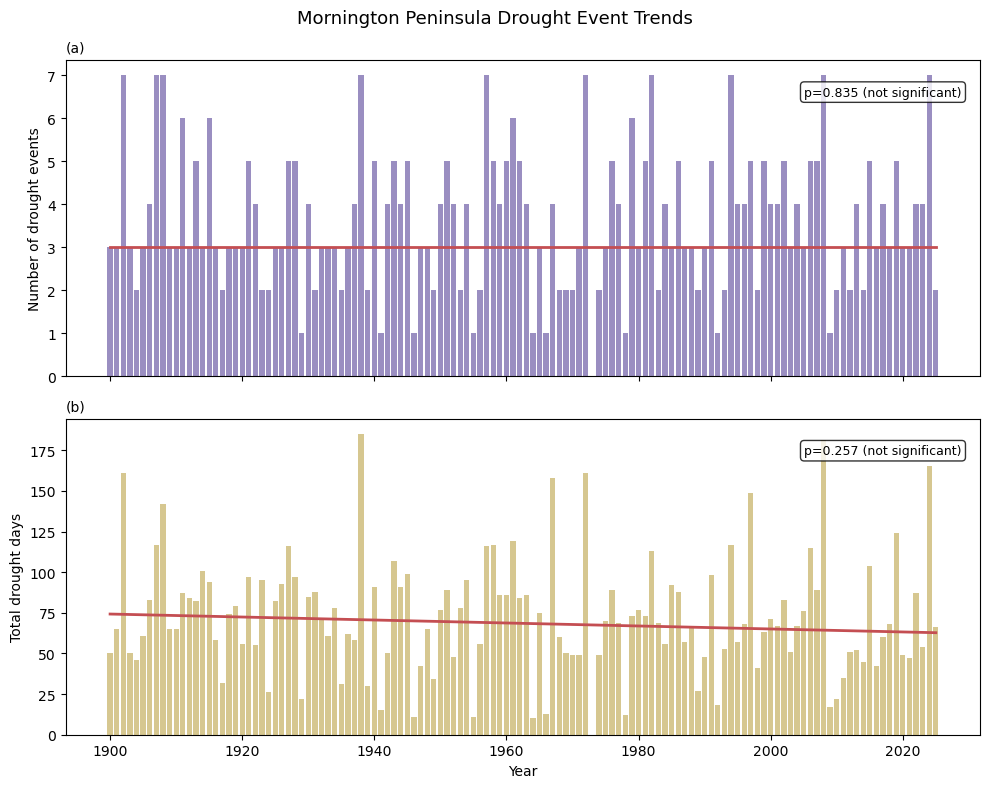

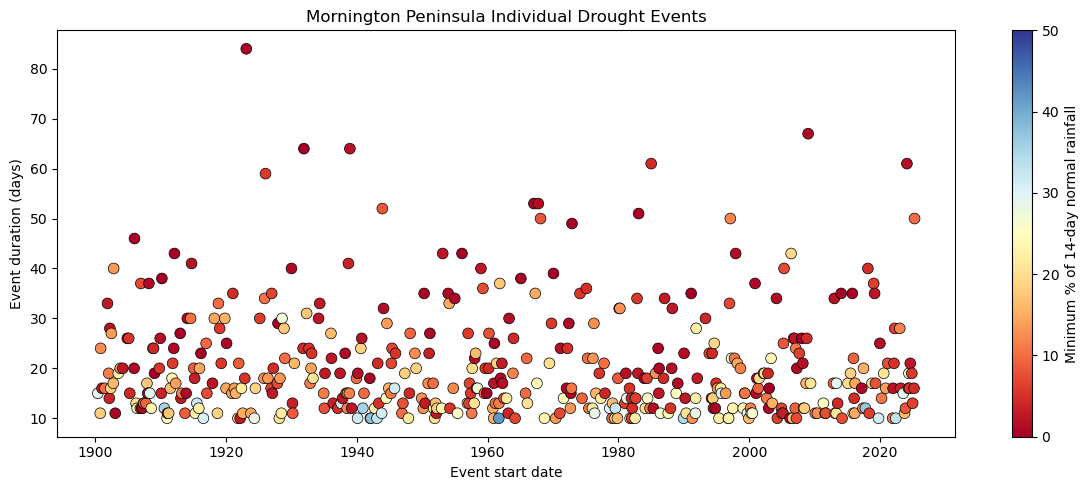

In [9]:
# --- Drought event detection (append after the seasonal rainfall section, replacing the dask cluster block) ---

ROLL_WINDOW_DAYS = 14
MIN_EVENT_LEN_DAYS = 10
DEFICIT_THRESHOLD_PCT = 50

# Reuse precip_box_mean (already computed earlier in this script) instead of a separate dask pipeline
precip_daily = precip_box_mean

# 14-day rolling sum (trailing window)
roll_sum = precip_daily.rolling(time=ROLL_WINDOW_DAYS, min_periods=ROLL_WINDOW_DAYS).sum()

# Day-of-year climatology of the rolling sum
doy = roll_sum['time'].dt.dayofyear
roll_sum_climatology = roll_sum.groupby(doy).mean(skipna=True)
climatology_expanded = roll_sum_climatology.sel(dayofyear=doy)

pct_of_normal = 100 * roll_sum / climatology_expanded

df = pd.DataFrame({
    'time': precip_daily['time'].values,
    'roll_sum': roll_sum.values,
    'pct_of_normal': pct_of_normal.values,
})
df = df.dropna(subset=['pct_of_normal']).reset_index(drop=True)
df['is_deficit'] = df['pct_of_normal'] < DEFICIT_THRESHOLD_PCT

df['run_id'] = (df['is_deficit'] != df['is_deficit'].shift()).cumsum()

events = []
for run_id, group in df[df['is_deficit']].groupby('run_id'):
    duration = len(group)
    if duration < MIN_EVENT_LEN_DAYS:
        continue
    events.append({
        'start': group['time'].iloc[0],
        'end': group['time'].iloc[-1],
        'duration_days': duration,
        'min_pct_of_normal': group['pct_of_normal'].min(),
        'mean_pct_of_normal': group['pct_of_normal'].mean(),
        'year': pd.Timestamp(group['time'].iloc[0]).year,
    })

events_df = pd.DataFrame(events)
print(f"\nIdentified {len(events_df)} drought events "
      f"(>= {MIN_EVENT_LEN_DAYS} days below {DEFICIT_THRESHOLD_PCT}% of the "
      f"{ROLL_WINDOW_DAYS}-day normal)")

year_range = np.arange(int(df['time'].min().year), int(df['time'].max().year) + 1)

annual_drought = pd.DataFrame({'year': year_range})
annual_drought['n_events'] = annual_drought['year'].map(
    events_df.groupby('year').size()).fillna(0)
annual_drought['total_drought_days'] = annual_drought['year'].map(
    events_df.groupby('year')['duration_days'].sum()).fillna(0)
annual_drought['mean_duration_days'] = annual_drought['year'].map(
    events_df.groupby('year')['duration_days'].mean())
annual_drought['min_pct_of_normal'] = annual_drought['year'].map(
    events_df.groupby('year')['min_pct_of_normal'].min())

drought_trend_results = {}
for metric in ['n_events', 'total_drought_days']:
    vals = annual_drought[metric].values.astype(float)
    yrs = annual_drought['year'].values.astype(float)
    drought_trend_results[metric] = trend_stats(yrs, vals)
    print(f"\n{metric} trend: {fmt_trend_label(drought_trend_results[metric])}, "
          f"Sen's slope = {drought_trend_results[metric]['sen_slope_per_decade']:.2f} per decade")

panel_letters = ['(a)', '(b)']

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for ax, metric, ylabel, color, letter in zip(
    axes,
    ['n_events', 'total_drought_days'],
    ['Number of drought events', 'Total drought days'],
    ['#8172B2', '#CCB974'],
    panel_letters
):
    yrs = annual_drought['year'].values.astype(float)
    vals = annual_drought[metric].values.astype(float)
    tstats = drought_trend_results[metric]

    ax.bar(yrs, vals, color=color, alpha=0.8)
    mask = ~np.isnan(vals)
    fit_line = tstats['sen_intercept'] + (tstats['sen_slope_per_decade'] / 10) * yrs[mask]
    ax.plot(yrs[mask], fit_line, color='#C44E52', linewidth=2)
    ax.set_ylabel(ylabel)
    ax.set_title(letter, fontsize=10, loc='left')
    ax.text(0.98, 0.92, fmt_trend_label(tstats),
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[-1].set_xlabel('Year')
fig.suptitle(f'Mornington Peninsula Drought Event Trends', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 1])
fig.savefig('mornington_drought_event_trends.png', dpi=200)
print("Saved: mornington_drought_event_trends.png")

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(
    events_df['start'], events_df['duration_days'],
    c=events_df['min_pct_of_normal'], cmap='RdYlBu',
    s=60, edgecolor='k', linewidth=0.5, vmin=0, vmax=DEFICIT_THRESHOLD_PCT
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(f'Minimum % of {ROLL_WINDOW_DAYS}-day normal rainfall')
ax.set_xlabel('Event start date')
ax.set_ylabel('Event duration (days)')
ax.set_title('Mornington Peninsula Individual Drought Events')
fig.tight_layout()
fig.savefig('mornington_drought_events_timeline.png', dpi=200)
print("Saved: mornington_drought_events_timeline.png")

print("\nAnnual drought metrics summary:")
print(annual_drought.to_string(index=False))